In [14]:
from xaikd import models, datasets, attributors
import numpy as np

from matplotlib import pyplot as plt

In [15]:
model = models.get_model("cifar100-resnet18-p1")

In [16]:
dataset = datasets.construct("cifar100-people")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [17]:
train_dl = datasets.build_dataloader(dataset.create_subset(train_split=True), shuffle=False)
val_dl = datasets.build_dataloader(dataset.create_subset(train_split=False), shuffle=False)

In [18]:
layer = "layer3"
arr_act, arr_ctx = attributors.extract_activation_context(
    model, 
    layer=layer, 
    dataset=dataset, 
    data_loader=train_dl,
    logit_modifier=attributors.OneClassEvidence(dataset),
    rng=np.random.default_rng(seed=1)
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [04:05<00:00,  6.13s/it]

layer3: output-dims=torch.Size([256, 8, 8])


In [21]:
def rel_recon_naive(activation, context):
    n, d = activation.shape
    rel_per_dim = (activation * context)
    rel = (rel_per_dim).sum(axis=1, keepdims=True)
    
    assert rel.shape == (n,1)
    
    criteria = np.mean((rel - rel_per_dim)**2, axis=0)
    
    indices = np.argsort(criteria)
    
    print(f"Top 10 Indices: {indices[:5]}")
    
    return indices, criteria[indices]

rel_recon_naive_indices, rel_recon_naive_criteria = rel_recon_naive(arr_act, arr_ctx)

Top 10 Indices: [165 115  39 129 249]


In [75]:
def rel_sqr(activation, context):
    n, d = activation.shape
    rel_per_dim = (activation * context)
#     rel = (rel_per_dim).sum(axis=1, keepdims=True)
    
#     assert rel.shape == (n,1)
    
    criteria = np.mean((rel_per_dim)**2, axis=0)
    
    indices = np.argsort(-criteria)
    
    print(f"Top 10 Indices: {indices[:5]}")
    
    return indices 

rel_sqr_indices = rel_sqr(arr_act, arr_ctx)

Top 10 Indices: [165 115  39 129 254]


In [22]:
from tqdm import tqdm
def rel_recon_greedy(activation, context):
        indices = []

        n, d = activation.shape

        indices = []
        objectives = []

        rel_per_dim = activation * context

        for step in tqdm(range(d)):
            dimensions = list(set(range(d)).difference(indices))

            stats = []

            rel_total_left = rel_per_dim[:, dimensions].sum(axis=1)

            for i in tqdm(dimensions, desc=f"step={step}"):
                rel_proj = rel_per_dim[:, i]
                norm = (rel_total_left - rel_proj) ** 2
                stat = float(norm.mean())
                stats.append(stat)

            _i = np.argmin(stats)
            k = dimensions[_i]
            indices.append(k)
            objectives.append(
                stats[_i]
            )

        return indices, objectives

rel_recon_greedy_indices, rel_recon_greedy_criteria = rel_recon_greedy(arr_act, arr_ctx)

step=10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 246/246 [00:00<00:00, 1832.91it/s]


step=21: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 235/235 [00:00<00:00, 1912.83it/s]


step=32: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 224/224 [00:00<00:00, 1965.28it/s]


step=43: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 213/213 [00:00<00:00, 1934.29it/s]


 21%|████████████████████████████████████████████▎                                                                                                                                                                 | 55/256 [00:13<00:41,  4.83it/s]


...

step=159: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97/97 [00:00<00:00, 2145.88it/s]

step=162: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 1960.73it/s]

step=164: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 92/92 [00:00<00:00, 1908.89it/s]

 65%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                       | 167/256 [00:30<00:09,  9.72it/s]


step=168: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:00<00:00, 1991.78it/s]

step=170: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:00<00:00, 1903.52it/s]

step=172: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [00:00<00:00, 1973.15it/s]

step=174: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82/82 [00:00<00:00, 1582.87it/s]

step=176: 100%|█

step=190: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 66/66 [00:00<00:00, 1578.50it/s]

step=192: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 1720.29it/s]

step=194: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 62/62 [00:00<00:00, 1959.73it/s]

step=196: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 1774.97it/s]

step=198: 100%|█

step=212: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 1663.27it/s]

step=214: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 1631.69it/s]

step=215: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:00<00:00, 1998.61it/s]

step=217: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39/39 [00:00<00:00, 2005.76it/s]

step=218: 100%|█

step=236: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 1439.88it/s]

step=237: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 1625.57it/s]

step=238: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 1612.02it/s]

step=239: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 1908.65it/s]

step=241: 100%|█

In [48]:
rel_recon_naive_indices[:20]

array([165, 115,  39, 129, 249, 176, 188, 254,  65, 191, 122, 251, 109,
        60,  16,  38, 152, 214, 178, 167])

In [70]:
def gen_canonical_basis(indices):
    
    I = np.eye(len(indices))
    
    return I[:, indices]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:03<00:00, 81.02it/s]


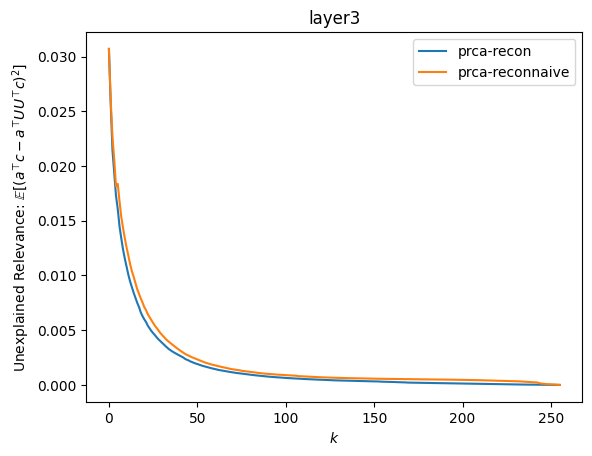

In [114]:
# def viz():
    
#     total_rel = rel_per_dim.sum(axis=1)
#     n, d = rel_per_dim.shape
    
#     layer = "layer3"
    
#     arr_basese = [
#         ("prca-recon", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-recon--centered/eigvecs.npy")),
#         ("prca-reconnaive", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-reconnaive--centered/eigvecs.npy")),

#     ]
    
#     for label, U in [
# #         ("relrecon-naive", gen_canonical_basis(rel_recon_naive_indices)),
# #         ("relrecon-correction", gen_canonical_basis(rel_recon_greedy_indices)),
# #         ("relsqr", gen_canonical_basis(rel_sqr_indices)),
#         ("prca-recon", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-recon--centered/eigvecs.npy")),
#         ("prca-reconnaive", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-reconnaive--centered/eigvecs.npy")),
#     ]:
        
#         stats = []
        
#         rel_on_U = (arr_act @ U) * (arr_ctx @ U) 
#         rel_accu = np.zeros((n, d))
#         for i in tqdm(range(d)):
#             rel_accu[:, i] = rel_on_U[:, i]

#             stats.append(
#                 np.mean(
#                     (rel_per_dim.sum(axis=1) - rel_accu.sum(axis=1)) **2
#                 )
#             )
        
#         plt.plot(stats, label=label)
# #     plt.axhline(0, ls="--")
# #     plt.axhline(np.mean(rel_per_dim.sum(axis=1) **2), ls="-",  label="E[$r^2$]")
#     plt.ylabel("Unexplained Relevance: $\mathbb{E}[(a^\\top c - a^\\top U U^\\top c)^2$]")
#     plt.legend()
#     plt.xlabel("$k$")
# viz()
# #    
viz()

[ 1.49428888e-03  9.18487828e-05 -1.28041809e-03  5.07099669e-04]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:03<00:00, 83.33it/s]


[ 0.00149429 -0.00110862 -0.00167223  0.01154719]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:03<00:00, 84.54it/s]


prca-recon always decreasing= False
prca-reconnaive always decreasing= False


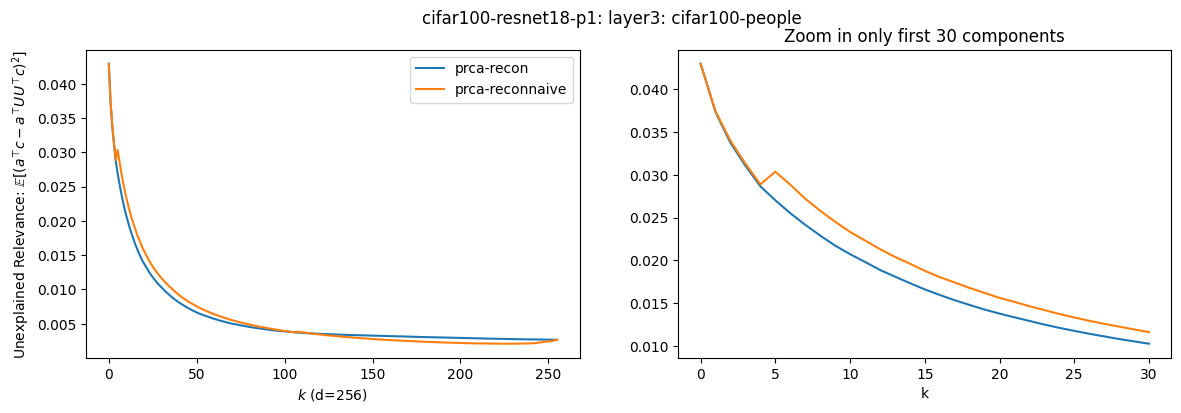

In [154]:
from pathlib import Path
def viz_unexplained_relevance_curve():

    
    total_rel = rel_per_dim.sum(axis=1)
    n, d = rel_per_dim.shape
    
    layer = "layer3"
    
    
    arr_bases = [
        ("prca-recon", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-recon--centered/eigvecs.npy")),
        ("prca-reconnaive", np.load(f"../../artifacts/2023-08-s10/dev/basis-accuracy/v8-compare-prcacorrection/cifar100-people--ts1.0-seed1/logit-mod-oneclass/cifar100-resnet18-p1/{layer}/prca-reconnaive--centered/eigvecs.npy")),
    ]
    
    act_mean = np.mean(arr_act, axis=0)
    arr_act_centered = (arr_act - act_mean)
    arr_stats = []
    for label, U in arr_bases:
        
        stats = []
        
        rel_on_U = (arr_act_centered @ U) * (arr_ctx @ U) 
        rel_accu = np.zeros((n, d))
        print(rel_on_U[0, :4])
        for i in tqdm(range(d)):
            rel_accu[:, i] = rel_on_U[:, i]

            stats.append(
                np.mean(
                    (rel_per_dim.sum(axis=1) - rel_accu.sum(axis=1)) **2
                )
            )
        arr_stats.append(stats)
    
    
    plt.figure(figsize=(7*2, 4))
    plt.suptitle("cifar100-resnet18-p1: layer3: cifar100-people")
    plt.subplot(1, 2, 1)
    for lix in range(len(arr_bases)):
        
        _s  = np.array(arr_stats[lix])
        
        print(arr_bases[lix][0], "always decreasing=", (_s[:-1] > _s[1:]).all())
        
        plt.plot(arr_stats[lix], label=arr_bases[lix][0])
        
    plt.ylabel("Unexplained Relevance: $\mathbb{E}[(a^\\top c - a^\\top U U^\\top c)^2$]")
    plt.legend()
    plt.xlabel(f"$k$ (d={d})")
    
    plt.subplot(1, 2, 2)
    
    kk = 30
    plt.title(f"Zoom in only first {kk} components")
    for lix in range(len(arr_bases)):
        
        plt.plot(arr_stats[lix][:kk+1], label=arr_bases[lix][0])
    plt.xlabel("k")
viz_unexplained_relevance_curve()        

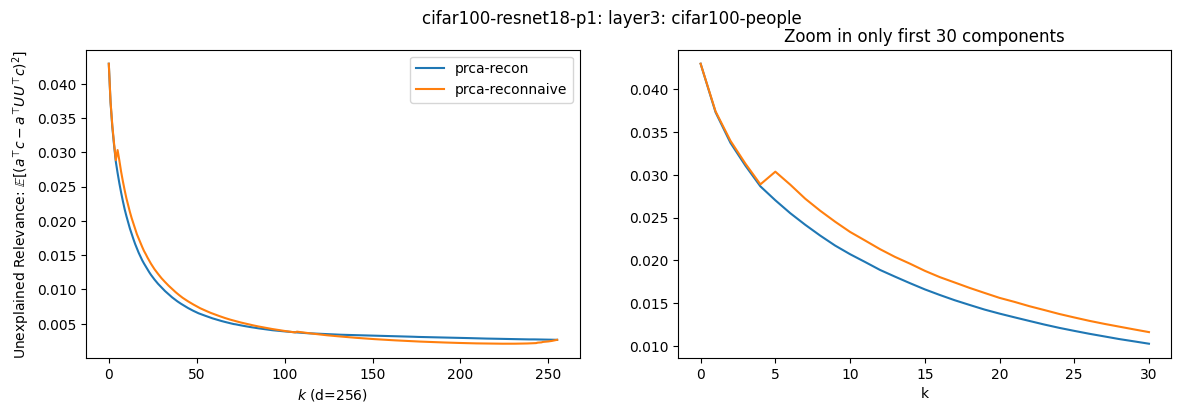

In [212]:
np.clip([-5, 2], a_min=0, a_max=None)

array([0, 2])

In [224]:
def approach_naive(r):
    indices = []
    
    d = len(r)
    possible_dimensions = set(range(d))
    
    total_rel = r.sum()
    
    for _ in range(d):
        dims = list(possible_dimensions.difference(indices))
        stats = []
        for k in dims:
            stats.append(
                (total_rel - r[k])**2
            )
        _i = np.argmin(stats)
        print(f'[step={_}]')
        indices.append(dims[_i])
        
    return indices

def clip_pos(x):
    return np.clip(x, a_min=0, a_max=None)

def clip_neg(x):
    return np.clip(x, a_max=0, a_min=None)

def approach_better(r):
    indices = []
    
    d = len(r)
    possible_dimensions = set(range(d))
    
    
    for _ in range(d):
        dims = list(possible_dimensions.difference(indices))
        stats = []
        
        total_rel_left = r[dims].sum()

        for k in dims:
            stats.append(
                (total_rel_left - r[k])**2
            )
        _i = np.argmin(stats)
        indices.append(dims[_i])
        
    return indices
    
def relu(x):
    return x * (x > 0)

def compute_unexplained_rel(r, indices):
    
    d = len(r)
    
    rel_ = np.zeros(d)
    
    
    total_r = r.sum()
    for i in range(d):
        # unexplained rel
        metric = (r - rel_).sum()**2
        metric_pos = (clip_pos(r) - clip_pos(rel_)).sum()**2

        metric_neg = (clip_neg(r) - clip_neg(rel_)).sum()**2

        k = indices[i]
        r_U = rel_.sum()
        rk = r[k]
        r_perp = r[indices[i+1:]].sum()

        r_delta = total_r - r_U
        print(f"[i={i}] unexplained rel={metric:.4f} | unex. posrel={metric_pos:.4f} | unex. negrel={metric_neg:.4f}")
        print(f"Pick `{k}`  total r={total_r:.4f}, r_U={r_U:.4f}, r_delta={r_delta:.4f}, r_k={rk:.4f}, r_perp={r_perp:.4f}")
        print(f"            >>> (r_k)^2 + r_k r_perp={rk**2 + rk*r_perp:.4f}")
        print("")
        rel_[k] = rk
        
def simple_case(case):
    r = np.array(case)
    
    indices_app_naive = approach_naive(r)
    print(f"R={r}")
    
    print("==== Approach 1 k=", indices_app_naive, "| Sorted R", r[indices_app_naive])
    compute_unexplained_rel(r, indices_app_naive)
    
    indices_app_better = approach_better(r)

    print("==== Approach 2 k=", indices_app_better, "| Sorted R", r[indices_app_better])
    compute_unexplained_rel(r, indices_app_better)


simple_case([1, -0.2, 0.1])

[step=0]
[step=1]
[step=2]
R=[ 1.  -0.2  0.1]
==== Approach 1 k= [0, 2, 1] | Sorted R [ 1.   0.1 -0.2]
[i=0] unexplained rel=0.8100 | unex. posrel=1.2100 | unex. negrel=0.0400
Pick `0`  total r=0.9000, r_U=0.0000, r_delta=0.9000, r_k=1.0000, r_perp=-0.1000
            >>> (r_k)^2 + r_k r_perp=0.9000

[i=1] unexplained rel=0.0100 | unex. posrel=0.0100 | unex. negrel=0.0400
Pick `2`  total r=0.9000, r_U=1.0000, r_delta=-0.1000, r_k=0.1000, r_perp=-0.2000
            >>> (r_k)^2 + r_k r_perp=-0.0100

[i=2] unexplained rel=0.0400 | unex. posrel=0.0000 | unex. negrel=0.0400
Pick `1`  total r=0.9000, r_U=1.1000, r_delta=-0.2000, r_k=-0.2000, r_perp=0.0000
            >>> (r_k)^2 + r_k r_perp=0.0400

==== Approach 2 k= [0, 1, 2] | Sorted R [ 1.  -0.2  0.1]
[i=0] unexplained rel=0.8100 | unex. posrel=1.2100 | unex. negrel=0.0400
Pick `0`  total r=0.9000, r_U=0.0000, r_delta=0.9000, r_k=1.0000, r_perp=-0.1000
            >>> (r_k)^2 + r_k r_perp=0.9000

[i=1] unexplained rel=0.0100 | unex. posr

In [223]:
simple_case([1, 9, 4, -11, -1])

[step=0]
[step=1]
[step=2]
[step=3]
[step=4]
R=[  1   9   4 -11  -1]
==== Approach 1 k= [0, 2, 4, 1, 3] | Sorted R [  1   4  -1   9 -11]
[i=0] unexplained rel=4.0000 | unex. posrel=196.0000 | unex. negrel=144.0000
Pick `0`  total r=2.0000, r_U=0.0000, r_delta=2.0000, r_k=1.0000, r_perp=1.0000
            >>> (r_k)^2 + r_k r_perp=2.0000

[i=1] unexplained rel=1.0000 | unex. posrel=169.0000 | unex. negrel=144.0000
Pick `2`  total r=2.0000, r_U=1.0000, r_delta=1.0000, r_k=4.0000, r_perp=-3.0000
            >>> (r_k)^2 + r_k r_perp=4.0000

[i=2] unexplained rel=9.0000 | unex. posrel=81.0000 | unex. negrel=144.0000
Pick `4`  total r=2.0000, r_U=5.0000, r_delta=-3.0000, r_k=-1.0000, r_perp=-2.0000
            >>> (r_k)^2 + r_k r_perp=3.0000

[i=3] unexplained rel=4.0000 | unex. posrel=81.0000 | unex. negrel=121.0000
Pick `1`  total r=2.0000, r_U=4.0000, r_delta=-2.0000, r_k=9.0000, r_perp=-11.0000
            >>> (r_k)^2 + r_k r_perp=-18.0000

[i=4] unexplained rel=121.0000 | unex. posrel=0.

In [194]:
simple_case([1.12869308, 0.79586214, 0.7347243,  0.74699621, 0.5295833 ])

[step=0]
[step=1]
[step=2]
[step=3]
[step=4]
R=[1.12869308 0.79586214 0.7347243  0.74699621 0.5295833 ]
==== Approach 1 k= [0, 1, 3, 2, 4] | Sorted R [1.12869308 0.79586214 0.74699621 0.7347243  0.5295833 ]
[i=0] unexplained rel=15.4910
Pick `0`  total r=3.9359, r_U=0.0000, r_delta=3.9359, r_k=1.1287, r_perp=2.8072
            >>> (r_k)^2 + r_k r_perp=4.4424

[i=1] unexplained rel=7.8802
Pick `1`  total r=3.9359, r_U=1.1287, r_delta=2.8072, r_k=0.7959, r_perp=2.0113
            >>> (r_k)^2 + r_k r_perp=2.2341

[i=2] unexplained rel=4.0453
Pick `3`  total r=3.9359, r_U=1.9246, r_delta=2.0113, r_k=0.7470, r_perp=1.2643
            >>> (r_k)^2 + r_k r_perp=1.5024

[i=3] unexplained rel=1.5985
Pick `2`  total r=3.9359, r_U=2.6716, r_delta=1.2643, r_k=0.7347, r_perp=0.5296
            >>> (r_k)^2 + r_k r_perp=0.9289

[i=4] unexplained rel=0.2805
Pick `4`  total r=3.9359, r_U=3.4063, r_delta=0.5296, r_k=0.5296, r_perp=0.0000
            >>> (r_k)^2 + r_k r_perp=0.2805

==== Approach 2 k= [0,